In [ ]:
# Подключаем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

In [30]:


# Задаем константы
ENV_PATH = r"./.env"
SQL_PATH = r"./v_machine_features_predictive.sql"
WORKING_PATH = r"./"



1. Забираем SQL скрипт и грузим в dataframe

In [31]:
# получение SQL скрипта
def read_sql_script(sql_path):
    with open(SQL_PATH, 'r', encoding='utf-8') as file:
        sql_script = file.read()
    return sql_script


# создаем строку соединения с базой
def create_connection_url(ENV_PATH):
    # загрузка переменных из .env
    load_dotenv(ENV_PATH)

    # Забираем креды
    host = os.getenv("DB_HOST")
    port = os.getenv("DB_PORT")
    database = os.getenv("DB_NAME")
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")

    # Создаем url для подключения
    return f"postgresql://{user}:{password}@{host}:{port}/{database}"

# загружаем данные из базы
def load_sql_data(engine, sql_script):
    return pd.read_sql(text(sql_script),engine)

# загружаем полученные данных в датафрейм pandas
def load_sql_to_pandas(sql_path, env_path):
    sql_script = read_sql_script(sql_path)
    conn_url = create_connection_url(env_path)
    engine = create_engine(conn_url)
    df = load_sql_data(engine, sql_script)
    return df


In [32]:
# Проверим, что загрузилось
print(read_sql_script(SQL_PATH))

WITH 
-- 1. Генерируем временную сетку для активных машин
time_grid AS (
    SELECT 
        m.machine_id,
        m.machine_name,
        m.commissioned_at,
        mt.type_name AS machine_type,
        generate_series(
            date_trunc('hour', '2025-01-10 07:00:00'::timestamp),
            date_trunc('hour', '2025-06-30 22:00:00'::timestamp),
            interval '1 hour'
        ) AS snapshot_time
    FROM machines m
    LEFT JOIN machine_types mt ON m.machine_type_id = mt.machine_type_id 
    WHERE m.status = 'ACTIVE'
),

-- 2. Пред-агрегируем показания сенсоров по часам (чтобы быстро обрабатывать миллионы строк телеметрии)
hourly_sensors AS (
    SELECT 
        s.machine_id,
        date_trunc('hour', sr.recorded_at) AS hr,
        AVG(CASE WHEN st.type_code = 'TEMPERATURE' THEN sr.numeric_value END) AS temp_hr,
        AVG(CASE WHEN st.type_code = 'VIBRATION' THEN sr.numeric_value END) AS vib_hr,
        AVG(CASE WHEN st.type_code = 'PRESSURE' THEN sr.numeric_value END) AS

In [ ]:
# создаем датафрейм
#df = load_sql_to_pandas(SQL_PATH, ENV_PATH)
df = pd.read_csv("./v_machine_features_predictive.csv", parse_dates=['snapshot_time'])

In [ ]:

# Проверяем датафрейм
df.head()



,machine_id,machine_name,machine_type,snapshot_time,temp_avg,temp_std,temp_trend,vib_avg,vib_std,vib_trend,...,humidity_trend,start_count,stop_count,downtime_seconds,breakdown_count_hist,operation_count,avg_op_duration_sec,age_days,days_since_maintenance,failure_next_24h
0,1,Фрезерный станок с ЧПУ №1,Фрезерный станок с ЧПУ,2025-01-10 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0.0,0,0,0.0,1983,10000,0
1,1,Фрезерный станок с ЧПУ №1,Фрезерный станок с ЧПУ,2025-01-10 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0.0,0,0,0.0,1984,10000,0
2,1,Фрезерный станок с ЧПУ №1,Фрезерный станок с ЧПУ,2025-01-10 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0.0,0,0,0.0,1984,10000,0
3,1,Фрезерный станок с ЧПУ №1,Фрезерный станок с ЧПУ,2025-01-10 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0.0,0,0,0.0,1984,10000,0
4,1,Фрезерный станок с ЧПУ №1,Фрезерный станок с ЧПУ,2025-01-10 11:00:00,65.900082,NaN,NaN,2.548091,NaN,NaN,...,NaN,1,0,420.0,0,1,3240.0,1984,10000,0


2. Агрегаты постоил ранее в представлении по кажому станку. 
Агрегировав данные по каждому часу для каждого станка.

3. Переходим к разведочному анализу данных

In [35]:
print("Размер данных:", df.shape)

Размер данных: (395520, 31)


In [36]:
print('Типы данных:')
df.info()

Типы данных:
<class 'pandas.DataFrame'>
RangeIndex: 395520 entries, 0 to 395519
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   machine_id              395520 non-null  int64         
 1   machine_name            395520 non-null  str           
 2   machine_type            395520 non-null  str           
 3   snapshot_time           395520 non-null  datetime64[us]
 4   temp_avg                41925 non-null   float64       
 5   temp_std                31955 non-null   float64       
 6   temp_trend              2482 non-null    float64       
 7   vib_avg                 26633 non-null   float64       
 8   vib_std                 20294 non-null   float64       
 9   vib_trend               1567 non-null    float64       
 10  press_avg               3543 non-null    float64       
 11  press_std               2714 non-null    float64       
 12  press_trend             241 

In [37]:

# Статистика для числовых признаков (описательная)
# Исключим идентификаторы и временные метки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Удалим столбцы, которые не являются признаками (например, machine_id, snapshot_time)
exclude_cols = ['machine_id', 'snapshot_time']  # если они есть в списке numeric
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print("\nОписательная статистика по числовым признакам:")
display(df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))


Описательная статистика по числовым признакам:


,temp_avg,temp_std,temp_trend,vib_avg,vib_std,vib_trend,press_avg,press_std,press_trend,rpm_avg,...,humidity_trend,start_count,stop_count,downtime_seconds,breakdown_count_hist,operation_count,avg_op_duration_sec,age_days,days_since_maintenance,failure_next_24h
count,41925.000000,31955.000000,2482.000000,26633.000000,20294.000000,1567.000000,3543.000000,2714.000000,241.000000,12188.000000,...,394.000000,395520.000000,395520.000000,395520.000000,395520.000000,395520.000000,395520.000000,395520.000000,395520.000000,395520.00000
mean,88.232056,2.192602,0.812318,2.555391,0.128602,0.033840,79.979752,0.755861,0.086082,2441.636683,...,0.029372,0.118045,0.118019,151.684466,0.002245,0.118045,513.867736,1786.271400,5145.691300,0.00891
std,44.888301,1.218570,3.554447,0.284660,0.200182,0.463421,0.754066,0.689147,1.629782,71.467110,...,1.655953,0.422659,0.421426,625.875870,0.047543,0.423274,1772.035932,1000.839293,4977.510845,0.09397
min,56.487931,0.000193,-14.124739,1.302610,0.000032,-2.960512,67.603867,0.002132,-12.041190,1600.313553,...,-7.470055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,108.000000,0.000000,0.00000
1%,64.403210,0.119798,-7.451685,2.292309,0.002803,-1.251742,77.924238,0.029993,-2.707590,2166.168207,...,-4.547872,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,171.000000,1.000000,0.00000
5%,65.625293,0.441203,-4.750148,2.385608,0.011522,-0.320516,78.993129,0.121783,-1.957869,2320.631818,...,-2.616210,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,331.000000,5.000000,0.00000
25%,67.098347,1.334417,-1.456418,2.463312,0.044122,-0.096123,79.678457,0.358359,-0.832962,2424.365351,...,-0.769692,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,902.000000,35.000000,0.00000
50%,68.357639,2.062239,0.800706,2.505094,0.076631,0.003195,80.009439,0.629553,0.081372,2456.076002,...,0.023863,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1689.000000,10000.000000,0.00000
75%,70.376021,2.888569,2.935260,2.550127,0.122712,0.091814,80.316142,0.925602,0.904862,2478.478813,...,0.872672,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2618.000000,10000.000000,0.00000
95%,188.972838,4.299754,7.069797,2.855464,0.483386,0.442152,80.903406,1.865260,2.077668,2515.380598,...,2.359810,1.000000,1.000000,1320.000000,0.000000,1.000000,5400.000000,3384.000000,10000.000000,0.00000


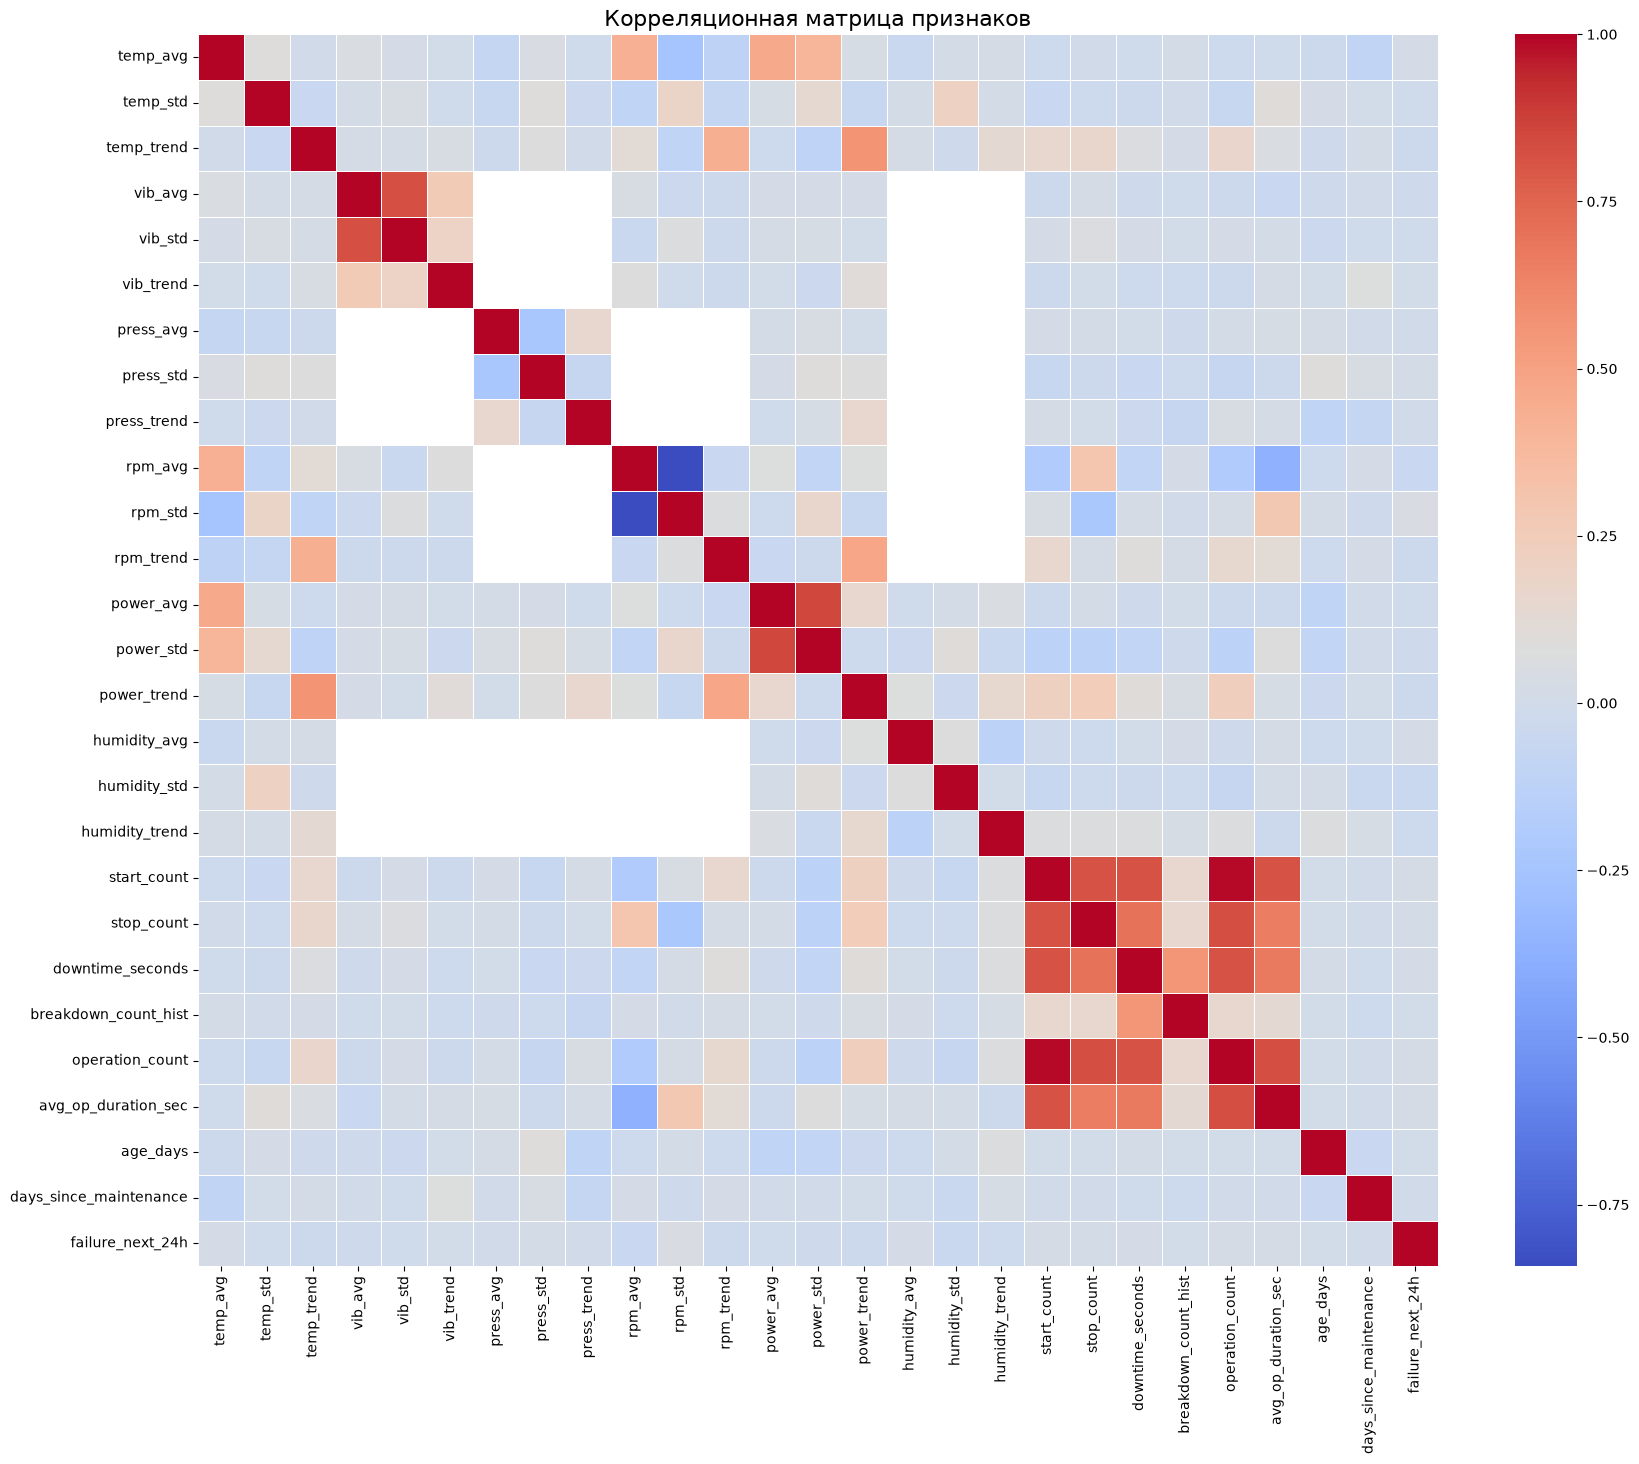

Корреляция признаков с целевой переменной (failure_next_24h):
failure_next_24h          1.000000
rpm_std                   0.044643
avg_op_duration_sec       0.026441
start_count               0.023490
operation_count           0.021994
downtime_seconds          0.018631
humidity_avg              0.018000
temp_avg                  0.016881
press_std                 0.012247
stop_count                0.009838
vib_trend                 0.005765
age_days                  0.003125
breakdown_count_hist      0.002314
days_since_maintenance   -0.001549
press_trend              -0.005894
press_avg                -0.006614
vib_std                  -0.007487
temp_std                 -0.011595
power_avg                -0.011643
power_std                -0.014629
vib_avg                  -0.015425
humidity_trend           -0.025140
power_trend              -0.032885
rpm_trend                -0.033233
temp_trend               -0.035888
humidity_std             -0.047164
rpm_avg                  -0.

In [38]:
# Вычислим корреляцию между всеми числовыми признаками (включая целевую)
corr_matrix = df[numeric_cols].corr()

# Построим тепловую карту
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title('Корреляционная матрица признаков', fontsize=16)
plt.show()

# Выведем топ-10 признаков, наиболее коррелирующих с целевой переменной
target_corr = corr_matrix['failure_next_24h'].sort_values(ascending=False)
print("Корреляция признаков с целевой переменной (failure_next_24h):")
print(target_corr)

Распределение целевой переменной:
failure_next_24h
0    391996
1      3524
Name: count, dtype: int64
Доля отказов: 0.89%


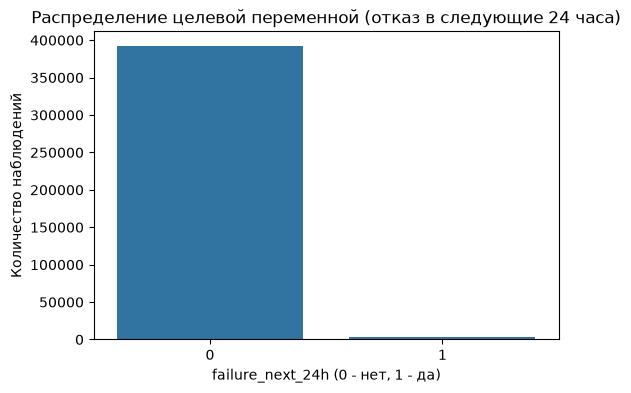

In [39]:
# Проверим баланс классов
target_counts = df['failure_next_24h'].value_counts()
print("Распределение целевой переменной:")
print(target_counts)
print(f"Доля отказов: {target_counts[1] / len(df) * 100:.2f}%")

# Визуализация
plt.figure(figsize=(6, 4))
sns.countplot(x='failure_next_24h', data=df)
plt.title('Распределение целевой переменной (отказ в следующие 24 часа)')
plt.xlabel('failure_next_24h (0 - нет, 1 - да)')
plt.ylabel('Количество наблюдений')
plt.show()

In [40]:
# Доля пропусков в каждом столбце
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)
print("Процент пропусков в столбцах (если есть):")
print(missing)

Процент пропусков в столбцах (если есть):
press_trend       99.939068
humidity_trend    99.900384
rpm_trend         99.807342
vib_trend         99.603813
power_trend       99.376517
temp_trend        99.372472
press_std         99.313815
press_avg         99.104217
humidity_std      98.649626
humidity_avg      98.222087
rpm_std           97.630714
rpm_avg           96.918487
vib_std           94.869033
vib_avg           93.266333
power_std         91.944276
temp_std          91.920763
power_avg         89.408627
temp_avg          89.400030
dtype: float64


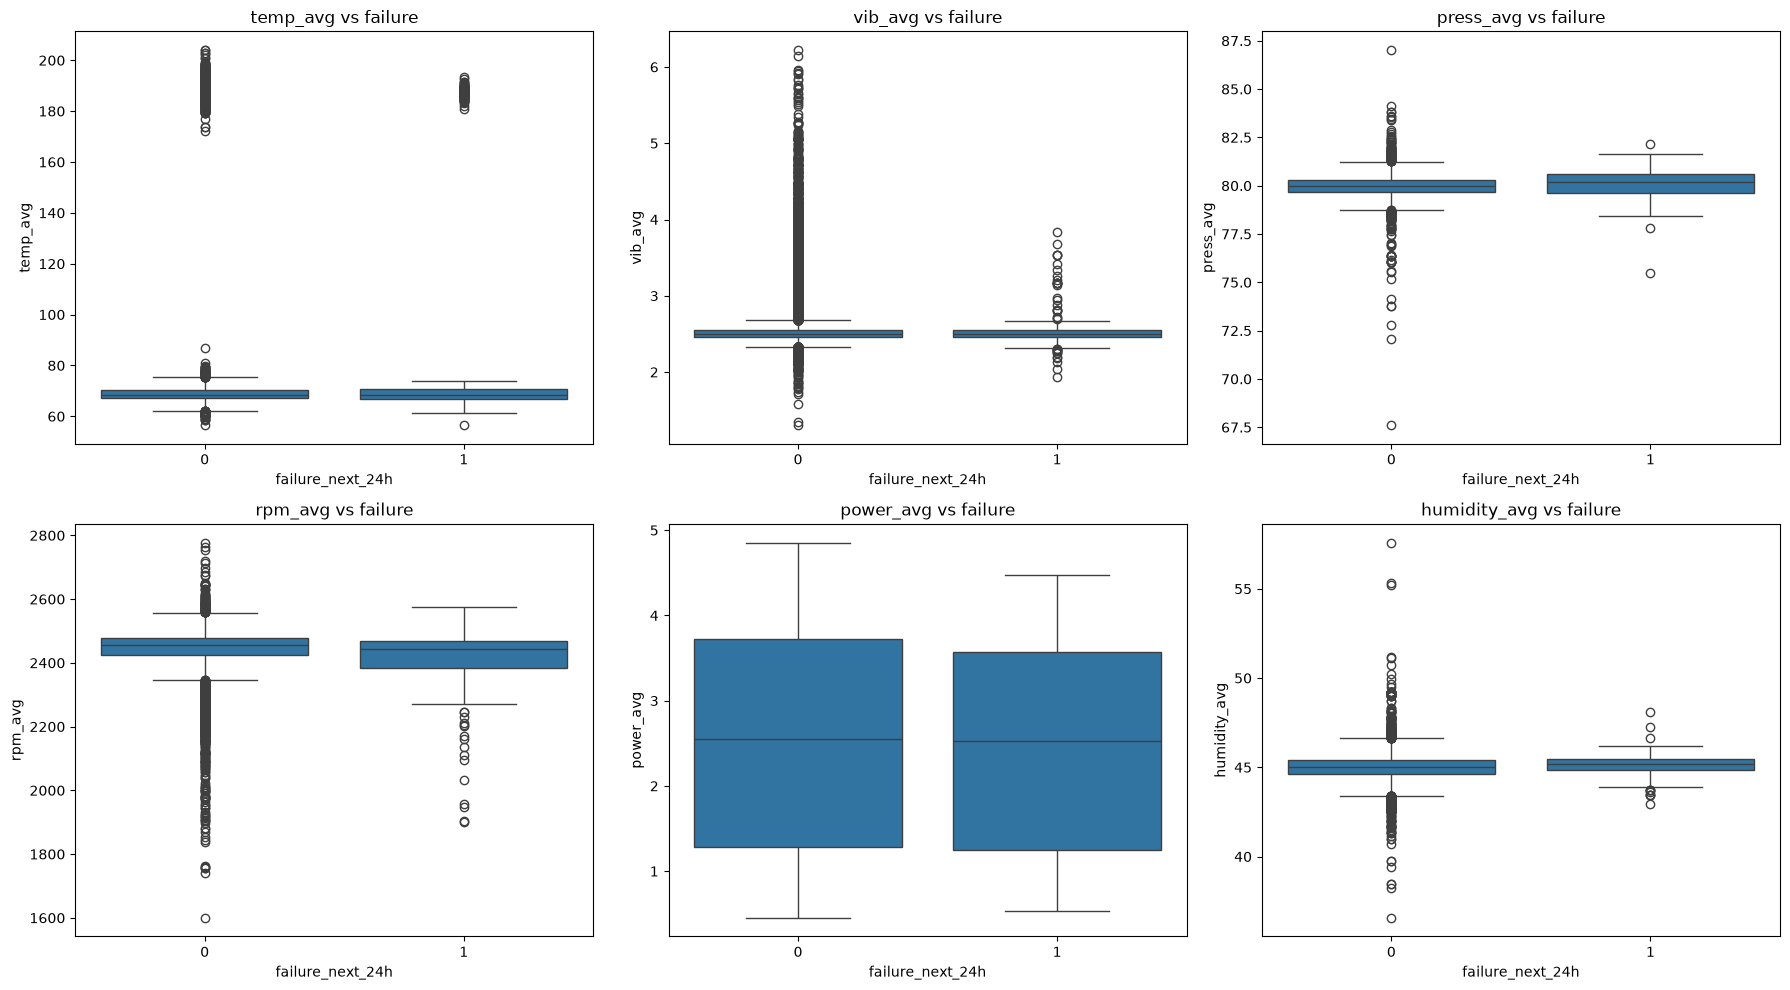

In [41]:
# Выберем все сенсорные столбцы (кроме trend, т.к. их много)
sensor_cols = ['temp_avg', 'vib_avg', 'press_avg', 'rpm_avg', 'power_avg', 'humidity_avg']
# Добавим также std и trend, но для краткости оставим только avg

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(sensor_cols):
    row = i // 3
    col_idx = i % 3
    sns.boxplot(x='failure_next_24h', y=col, data=df, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs failure')
plt.tight_layout()
plt.show()

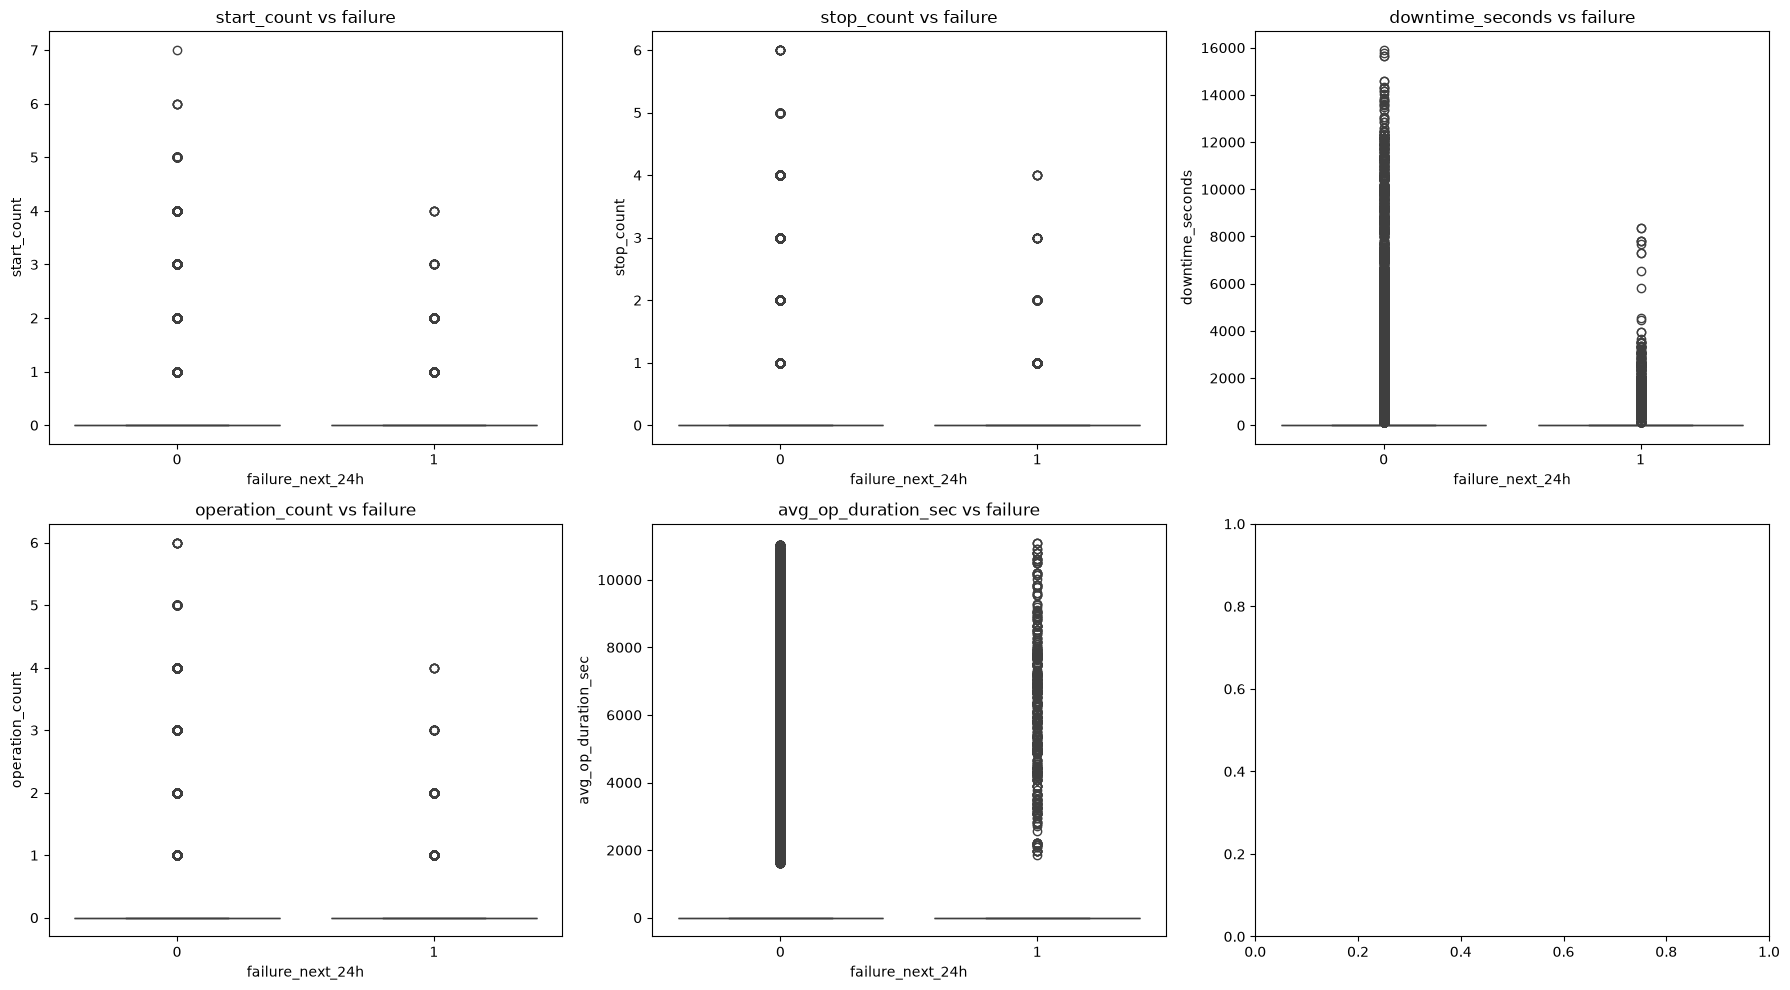

In [42]:
event_cols = ['start_count', 'stop_count', 'downtime_seconds', 'operation_count', 'avg_op_duration_sec']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(event_cols):
    row = i // 3
    col_idx = i % 3
    sns.boxplot(x='failure_next_24h', y=col, data=df, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs failure')
plt.tight_layout()
plt.show()

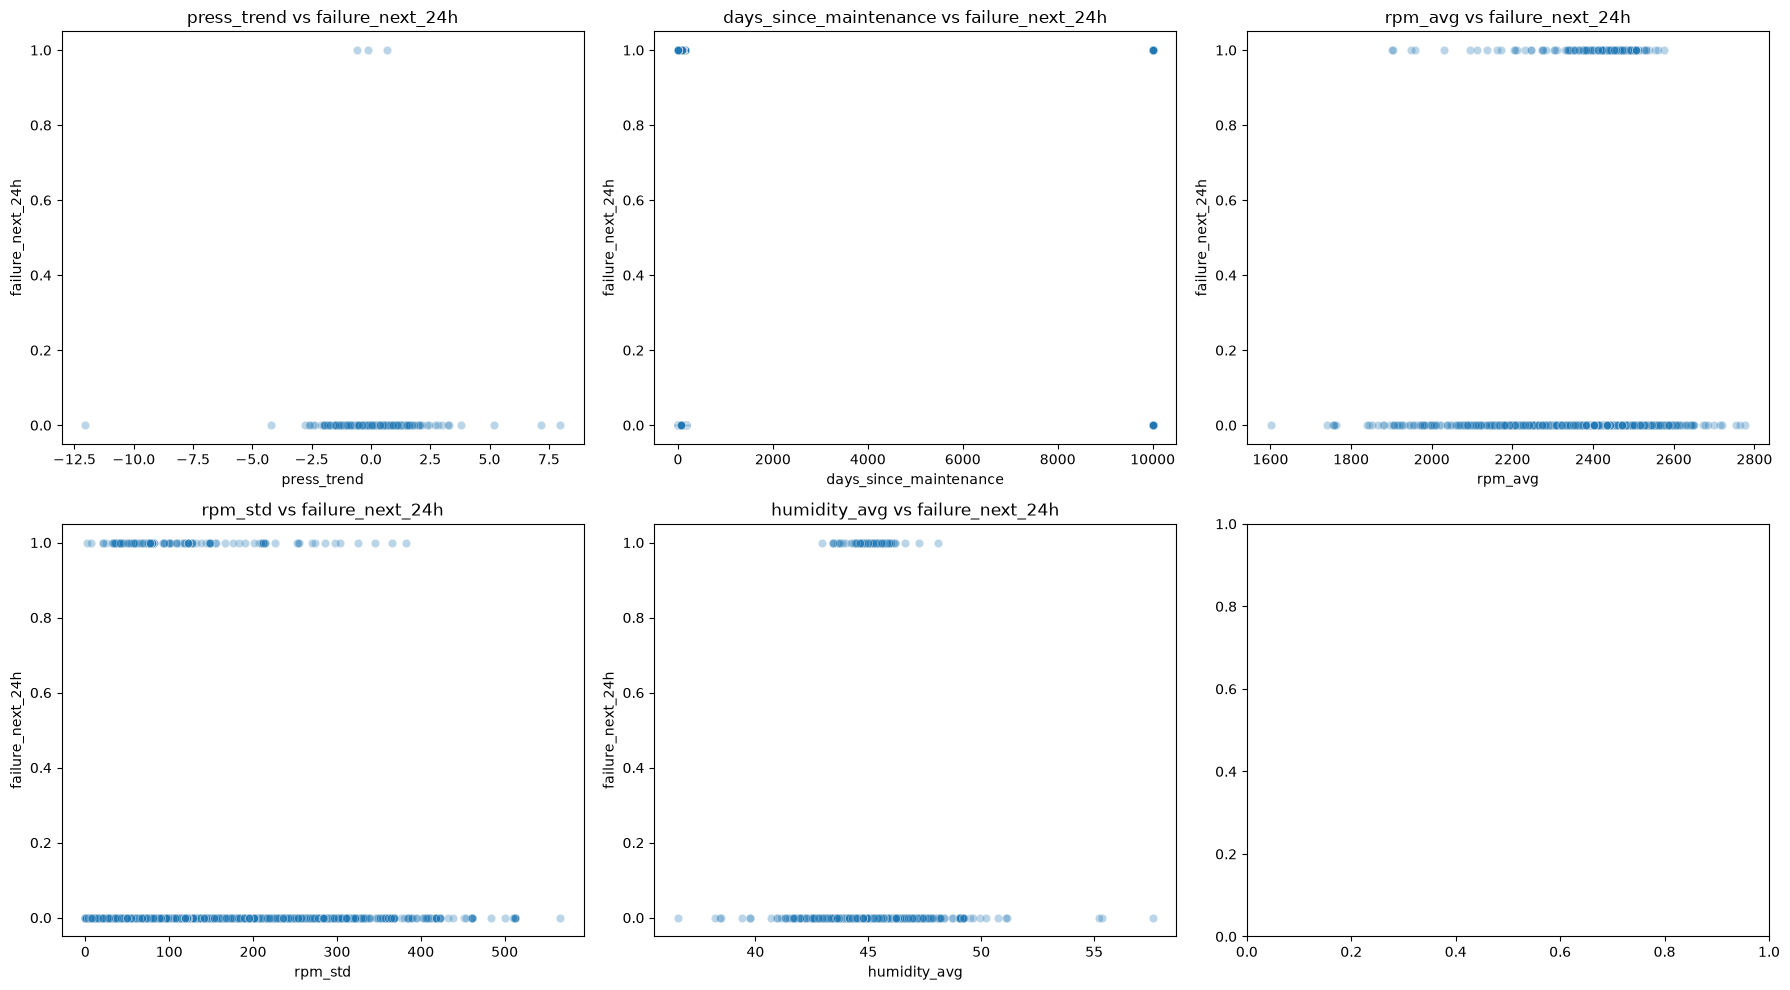

In [43]:
# Выберем топ-5 признаков по абсолютной корреляции с таргетом (кроме самого таргета)
top_features = ['press_trend', 'days_since_maintenance', 'rpm_avg', 'rpm_std', 'humidity_avg']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(top_features):
    row = i // 3
    col_idx = i % 3
    sns.scatterplot(x=col, y='failure_next_24h', data=df, alpha=0.3, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs failure_next_24h')
plt.tight_layout()
plt.show()

Станки с отказами: [ 1  2  3  5  6  7  8 11 12 13 15 17 18 20 21 22 23 26 27 28 29 30 32 33
 34 35 36 37 38 39 40 41 43 44 45 46 47 50 51 52 53 54 55 56 57 58 59 60
 61 63 64 65 67 68 69 70 73 74 75 77 78 79 80 84 85 86 87 89 90 91 92 93
 94 95]


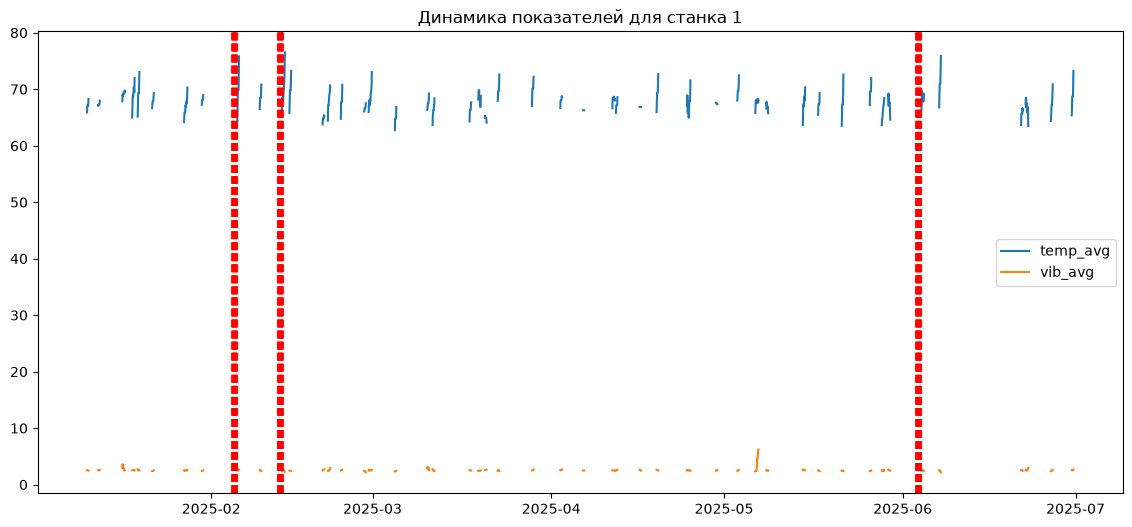

In [ ]:
# построим график динамики показадетелей станков и определим ID станков с отказами.
failure_machines = df[df['failure_next_24h'] == 1]['machine_id'].unique()
print("Станки с отказами:", failure_machines)

# Возьмём первый из списка
sample_machine = failure_machines[0] if len(failure_machines) > 0 else None
if sample_machine:
    sample_df = df[df['machine_id'] == sample_machine].sort_values('snapshot_time')
    plt.figure(figsize=(14, 6))
    plt.plot(sample_df['snapshot_time'], sample_df['temp_avg'], label='temp_avg')
    plt.plot(sample_df['snapshot_time'], sample_df['vib_avg'], label='vib_avg')
    # Отметим моменты, где failure_next_24h == 1
    failure_times = sample_df[sample_df['failure_next_24h'] == 1]['snapshot_time']
    for ft in failure_times:
        plt.axvline(x=ft, color='red', linestyle='--', alpha=0.5)
    plt.legend()
    plt.title(f'Динамика показателей для станка {sample_machine}')
    plt.show()

Очистка данных.
В данных очень много пропусков (от 89% до 99%). Это означает, что для большинства временных срезов показания сенсоров отсутствуют.
Применим следующий подход:

    Заполнение пропусков в сенсорных признаках — медианой по каждому станку, а если для станка нет ни одного показания — общей медианой по всему набору. Это позволит сохранить индивидуальные особенности станков и не потерять 90% строк (иначе мы бы не смогли построить модель).

    Обработка выбросов — поскольку выбросы могут быть предвестниками отказов, мы не будем их удалять, а вместо этого применим винсоризацию (ограничение экстремальных значений на уровне 99-го перцентиля), чтобы уменьшить их влияние, но сохранить информацию.

    Проверка корректности — убедимся, что после заполнения пропусков нет NaN.

Обоснование: медиана устойчива к выбросам и даёт типичное значение для каждого станка; винсоризация сохраняет выбросы, но ограничивает их влияние на модель.

In [45]:
# Список сенсорных столбцов
sensor_cols = ['temp_avg', 'temp_std', 'temp_trend', 'vib_avg', 'vib_std', 'vib_trend',
               'press_avg', 'press_std', 'press_trend', 'rpm_avg', 'rpm_std', 'rpm_trend',
               'power_avg', 'power_std', 'power_trend', 'humidity_avg', 'humidity_std', 'humidity_trend']

# Заполнение пропусков
for col in sensor_cols:
    # Шаг 1: заполняем медианой по каждому станку
    df[col] = df.groupby('machine_id')[col].transform(lambda x: x.fillna(x.median()))
    # Шаг 2: оставшиеся NaN (если станок вообще не имеет данных) заполняем общей медианой
    df[col] = df[col].fillna(df[col].median())

# Проверка пропусков
print("Пропуски после заполнения:", df[sensor_cols].isnull().sum().sum())  # должно быть 0

# Винсоризация выбросов (ограничение крайних 1%)
from scipy.stats.mstats import winsorize

for col in sensor_cols:
    # winsorize работает с массивами, но возвращает массив, поэтому присваиваем обратно
    df[col] = np.asarray(winsorize(df[col], limits=[0.01, 0.01]))

# Проверим статистику после очистки
print(df[sensor_cols].describe())

Пропуски после заполнения: 0
            temp_avg       temp_std     temp_trend        vib_avg  \
count  395520.000000  395520.000000  395520.000000  395520.000000   
mean       86.702400       2.067706       0.719271       2.504970   
std        43.564316       0.313416       0.835601       0.014970   
min        66.120182       0.859444      -2.438599       2.436276   
25%        67.829329       1.931393       0.174226       2.501777   
50%        67.968157       2.070902       0.757104       2.504798   
75%        68.225354       2.178974       1.321582       2.507622   
max       188.468257       3.566054       2.489622       2.587026   

             vib_std      vib_trend      press_avg      press_std  \
count  395520.000000  395520.000000  395520.000000  395520.000000   
mean        0.078382       0.003180      80.019187       0.620734   
std         0.011195       0.031182       0.016847       0.006734   
min         0.036595      -0.092108      79.938695       0.595019   
25% 

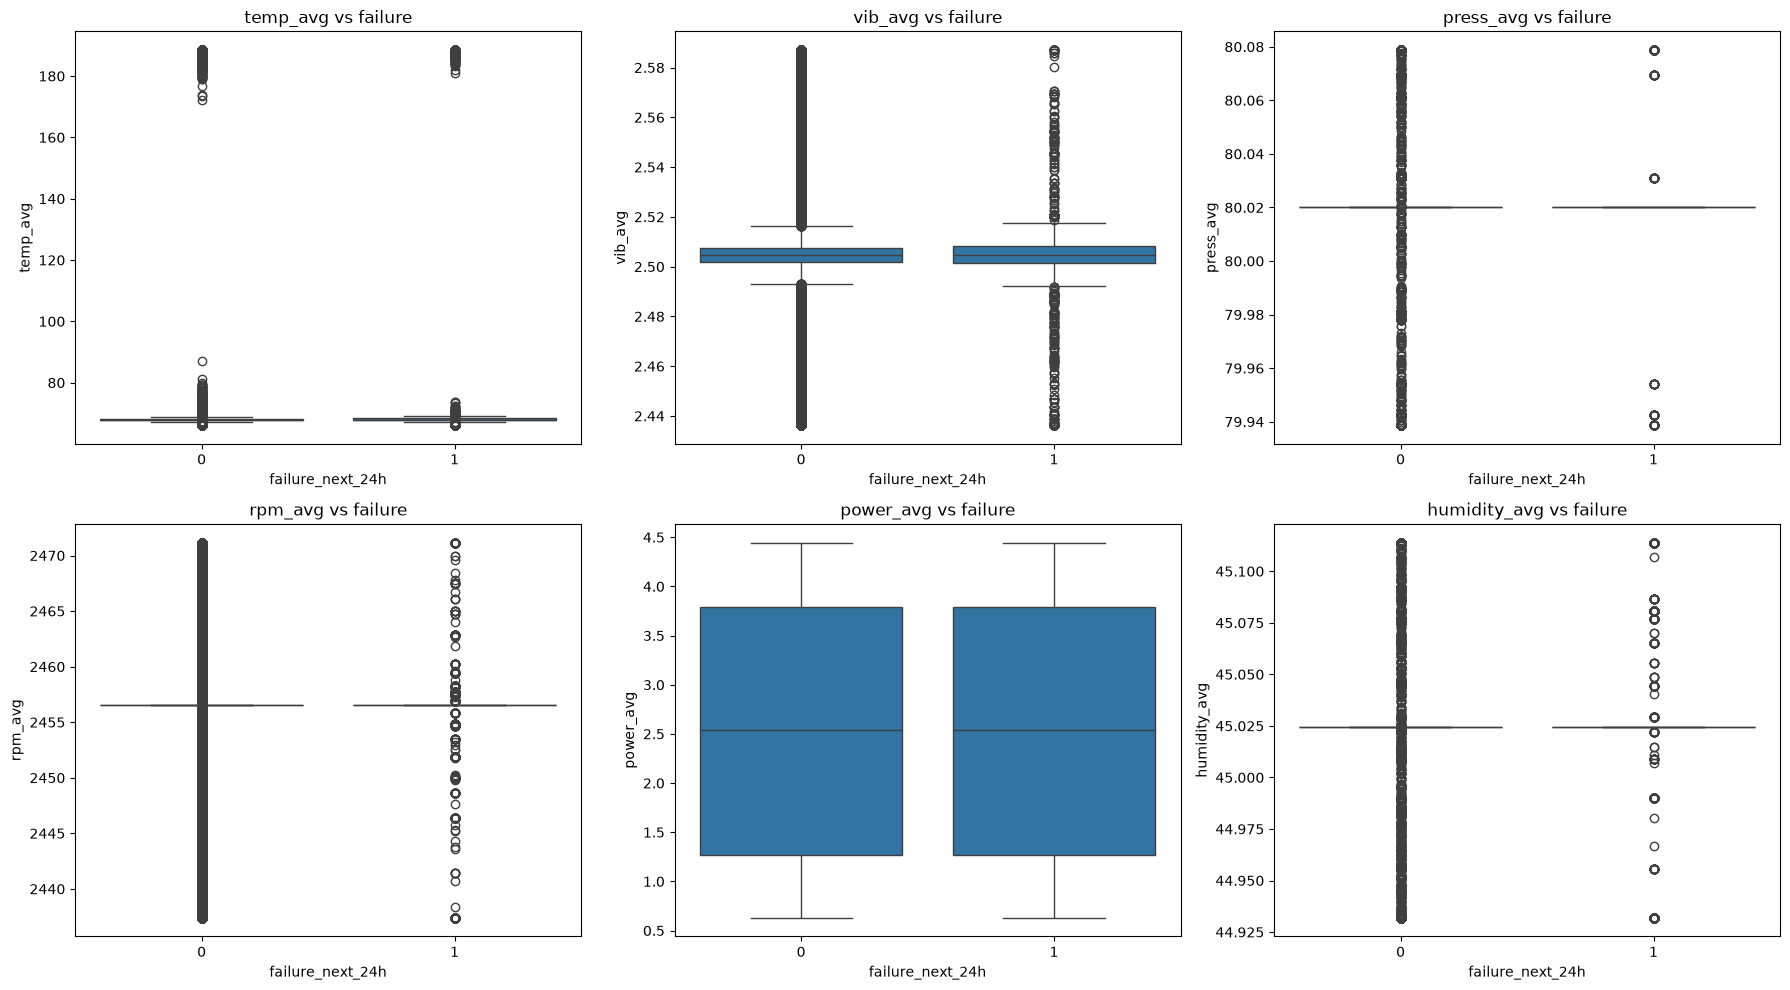

In [46]:

# Средние значения сенсоров
sensor_avg_cols = ['temp_avg', 'vib_avg', 'press_avg', 'rpm_avg', 'power_avg', 'humidity_avg']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(sensor_avg_cols):
    row = i // 3
    col_idx = i % 3
    sns.boxplot(x='failure_next_24h', y=col, data=df, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs failure')
plt.tight_layout()
plt.show()

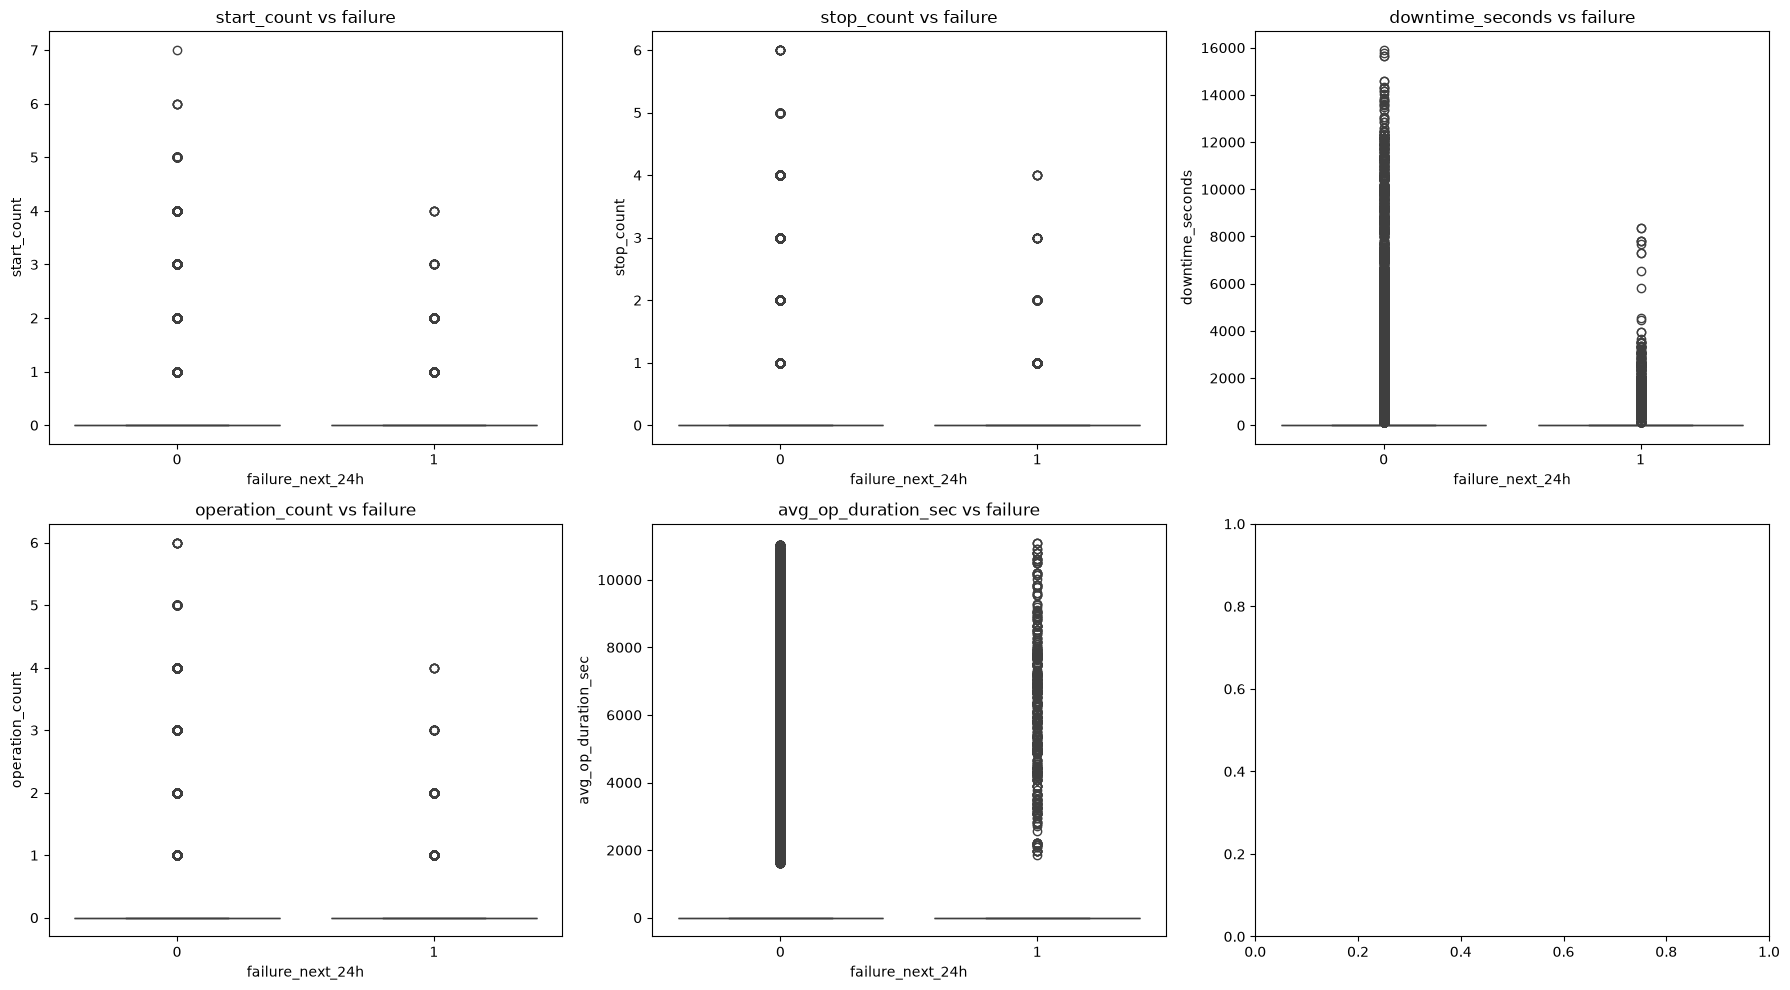

In [47]:
event_cols = ['start_count', 'stop_count', 'downtime_seconds', 'operation_count', 'avg_op_duration_sec']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(event_cols):
    row = i // 3
    col_idx = i % 3
    sns.boxplot(x='failure_next_24h', y=col, data=df, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs failure')
plt.tight_layout()
plt.show()

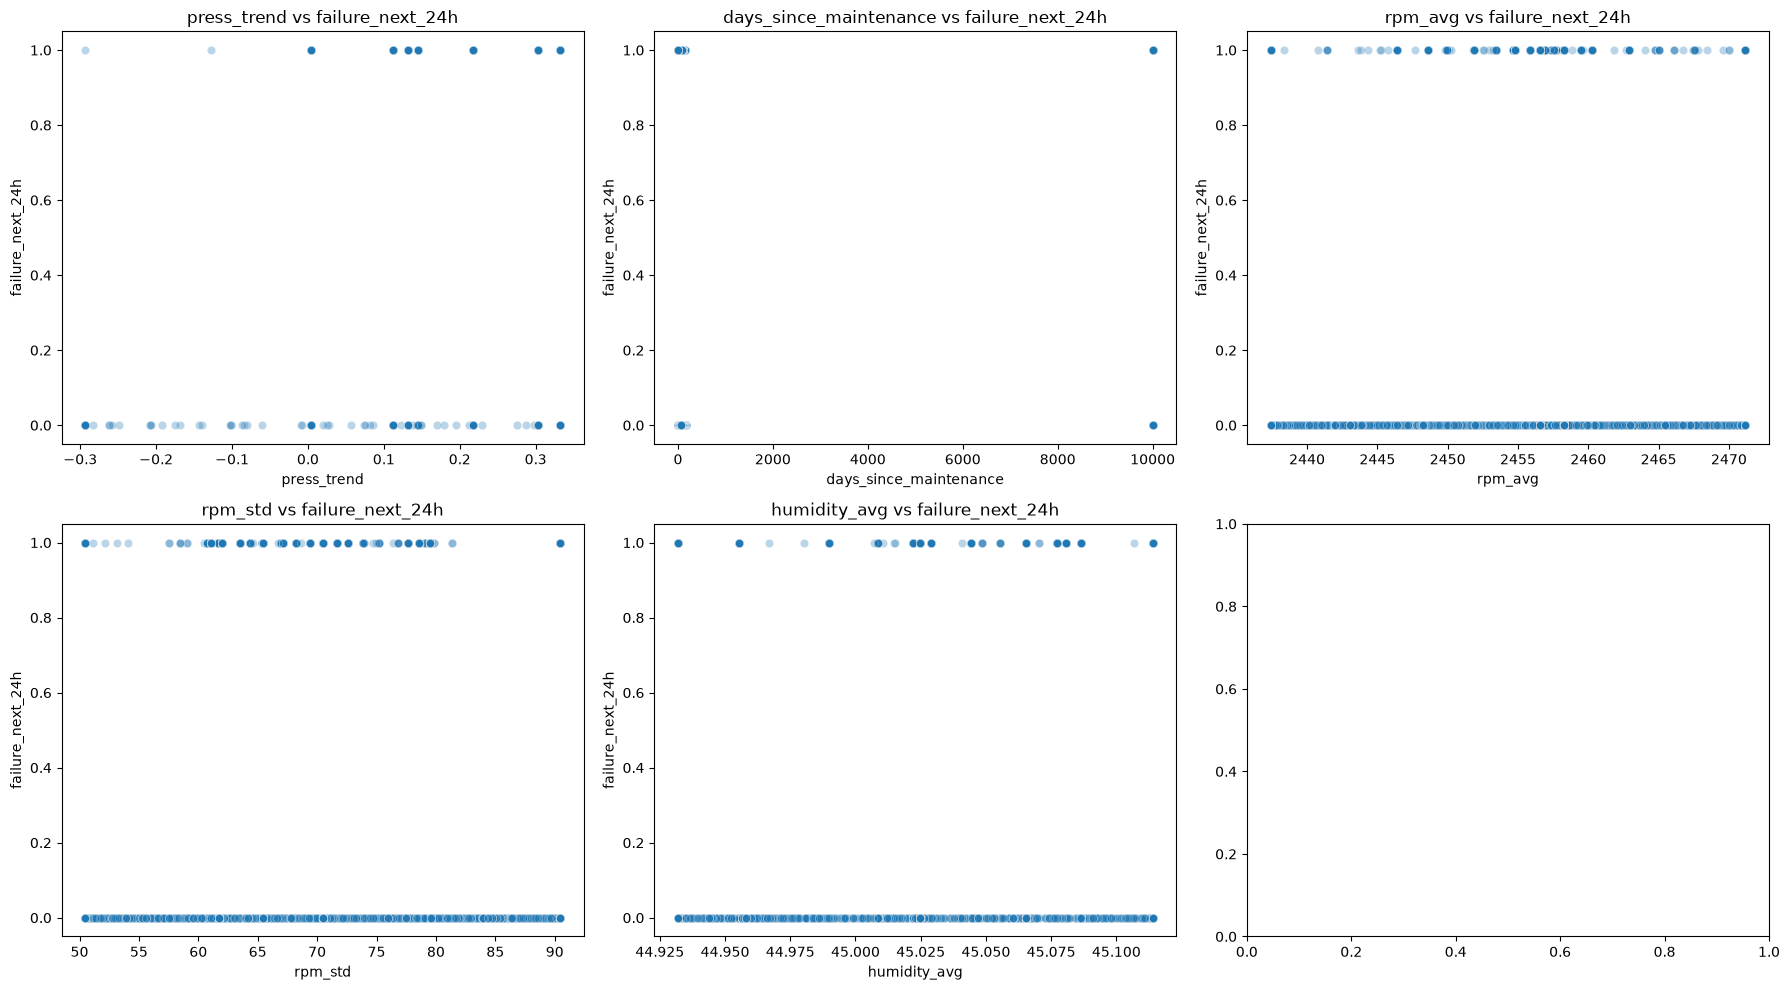

In [48]:
top_features = ['press_trend', 'days_since_maintenance', 'rpm_avg', 'rpm_std', 'humidity_avg']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(top_features):
    row = i // 3
    col_idx = i % 3
    sns.scatterplot(x=col, y='failure_next_24h', data=df, alpha=0.3, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs failure_next_24h')
plt.tight_layout()
plt.show()

Станки с отказами: [ 1  2  3  5  6  7  8 11 12 13 15 17 18 20 21 22 23 26 27 28 29 30 32 33
 34 35 36 37 38 39 40 41 43 44 45 46 47 50 51 52 53 54 55 56 57 58 59 60
 61 63 64 65 67 68 69 70 73 74 75 77 78 79 80 84 85 86 87 89 90 91 92 93
 94 95]


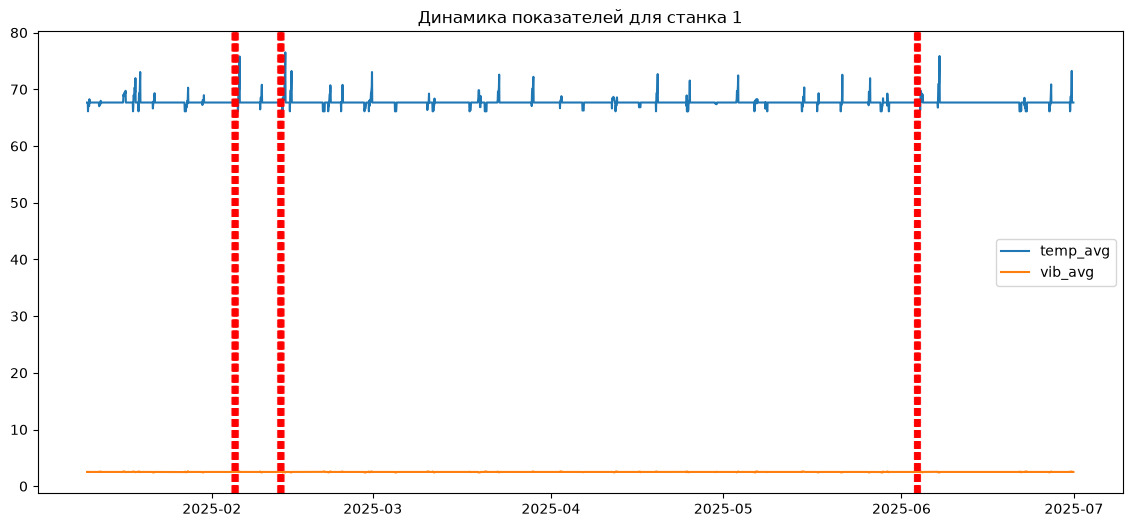

In [49]:
# Найдём станки, у которых есть отказы
failure_machines = df[df['failure_next_24h'] == 1]['machine_id'].unique()
print("Станки с отказами:", failure_machines)

if len(failure_machines) > 0:
    sample_machine = failure_machines[0]
    sample_df = df[df['machine_id'] == sample_machine].sort_values('snapshot_time')
    plt.figure(figsize=(14, 6))
    plt.plot(sample_df['snapshot_time'], sample_df['temp_avg'], label='temp_avg')
    plt.plot(sample_df['snapshot_time'], sample_df['vib_avg'], label='vib_avg')
    # Отметим моменты, где failure_next_24h == 1
    failure_times = sample_df[sample_df['failure_next_24h'] == 1]['snapshot_time']
    for ft in failure_times:
        plt.axvline(x=ft, color='red', linestyle='--', alpha=0.5)
    plt.legend()
    plt.title(f'Динамика показателей для станка {sample_machine}')
    plt.show()

In [ ]:
#для проверки гипотез проведем непараметрический тест Манна-Уитни
from scipy.stats import mannwhitneyu

# Собираем все исследуемые признаки в один список
features_to_test = [
    'temp_avg', 'vib_avg', 'days_since_maintenance', 'press_trend', 'start_count',
    'rpm_avg', 'rpm_std', 'temp_std', 'vib_std', 'humidity_std'
]

results = []

# Проводим тест Манна-Уитни для каждого признака
for col in features_to_test:
    stat, p = mannwhitneyu(
        df[df['failure_next_24h'] == 0][col], 
        df[df['failure_next_24h'] == 1][col],
        nan_policy='omit' # на всякий случай игнорируем NaN, если они где-то остались
    )
    status = 'значимо' if p < 0.05 else 'не значимо'
    results.append({'feature': col, 'p_value': p, 'status': status})

# Сохраняем в DataFrame для красивого вывода и сортируем по p-value (от самых значимых)
df_results = pd.DataFrame(results).sort_values(by='p_value')

print("Результаты проверки статистической значимости признаков (U-тест Манна-Уитни):")
for idx, row in df_results.iterrows():
    print(f"{row['feature']}: p-value = {row['p_value']:.4f} ({row['status']})")


Результаты проверки статистической значимости признаков (U-тест Манна-Уитни):
start_count: p-value = 0.0000 (значимо)
rpm_std: p-value = 0.0000 (значимо)
press_trend: p-value = 0.0002 (значимо)
temp_std: p-value = 0.0003 (значимо)
rpm_avg: p-value = 0.0039 (значимо)
vib_std: p-value = 0.0115 (значимо)
temp_avg: p-value = 0.0427 (значимо)
humidity_std: p-value = 0.1394 (не значимо)
days_since_maintenance: p-value = 0.5131 (не значимо)
vib_avg: p-value = 0.5472 (не значимо)
